<a href="https://colab.research.google.com/github/roza217/EXEMPLE/blob/main/UrbanRetail_Data_Analysis_Roza_Chentoufi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Projet de Business Intelligence & Data Analysis : UrbanRetail
**Étudiante :** Roza Chentoufi  
**Objectif :** Nettoyer un jeu de données de vente "dirty", structurer une analyse de performance commerciale, et restituer un tableau de bord visuel pour répondre aux besoins de 5 départements métiers (Direction, Commercial, Marketing, Finance).

---

## 🚀 Introduction & Architecture du Projet
Pour ce projet, nous avons adopté une approche structurée en 4 étapes majeures :
1. **Extraction & Chargement** des données brutes.
2. **Data Cleaning & Préparation** (Gestion des doublons, traitement des anomalies de prix/quantités, standardisation textuelle).
3. **Analyse Statistique** (Calcul des KPIs et agrégations par axes analytiques).
4. **Data Visualization** (Création d'un dashboard décisionnel).

Commençons par importer les bibliothèques fondamentales.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration globale des graphiques
sns.set_theme(style="whitegrid")
%matplotlib inline

## 🛠️ Étape 1 : Chargement des Données (Data Loading)
Nous chargeons le fichier de ventes initial afin de vérifier sa bonne intégration avant toute manipulation.

In [3]:
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        print(f"✅ Données chargées avec succès. Taille initiale : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
        return df
    except Exception as e:
        print(f"❌ Erreur lors du chargement : {e}")
        return None

# Chargement du fichier
df_raw = load_data('urban_retail_sales_dirty.csv')
# Visualisation des 5 premières lignes du fichier brut
df_raw.head()

❌ Erreur lors du chargement : [Errno 2] No such file or directory: 'urban_retail_sales_dirty.csv'


AttributeError: 'NoneType' object has no attribute 'head'

## 🧹 Étape 2 : Nettoyage et Harmonisation des Données (Data Cleaning)
Le jeu de données d'origine présente plusieurs incohérences critiques que nous devons corriger pour garantir la fiabilité des analyses :
* **Doublons :** Lignes répétées à éliminer.
* **Villes (City) :** Espaces superflus et casses hétérogènes (ex: "paris ", "Paris").
* **Quantités négatives :** Correction par valeur absolue.
* **Prix Unitaires (Unit_Price) manquants :** Calculés à partir du `Revenue` s'il existe, sinon complétés par la *médiane* (plus robuste que la moyenne face aux valeurs aberrantes).
* **Chiffre d'Affaires (Revenue) :** Recalculé strictement ($Unit\_Price \times Quantity$) pour éliminer les corruptions de données.
* **Dates :** Forçage au format datetime européen (`dayfirst=True`).

In [ ]:
def clean_data(df):
    df = df.copy()

    # 1. Suppression des doublons
    df = df.drop_duplicates()

    # 2. Harmonisation des villes
    df['City'] = df['City'].astype(str).str.strip().str.capitalize()
    df['City'] = df['City'].replace(['', 'Nan', 'None'], 'Inconnu')

    # 3. Conversion des types numériques
    for col in ['Unit_Price', 'Quantity', 'Revenue', 'Rating']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4. Correction des quantités négatives ou nulles
    df['Quantity'] = df['Quantity'].apply(lambda x: abs(x) if pd.notnull(x) and x != 0 else 1)

    # 5. Recalcul cohérent des Prix et du Chiffre d'Affaires
    mask_price_missing = df['Unit_Price'].isnull() & df['Revenue'].notnull()
    df.loc[mask_price_missing, 'Unit_Price'] = df['Revenue'] / df['Quantity']

    median_price = df['Unit_Price'].median()
    df['Unit_Price'] = df['Unit_Price'].fillna(median_price if pd.notnull(median_price) else 0)

    # Recalcul strict du Chiffre d'Affaires
    df['Revenue'] = df['Unit_Price'] * df['Quantity']

    # 6. Remplissage des valeurs catégorielles manquantes
    df['Payment_Method'] = df['Payment_Method'].fillna('Inconnu')
    df['Product_Category'] = df['Product_Category'].fillna('Non spécifié')

    # 7. Gestion des dates
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
    df = df.dropna(subset=['Date'])

    print(f"✅ Nettoyage terminé. Lignes valides prêtes pour l'analyse : {len(df)}")
    return df

# Exécution du nettoyage
df_clean = clean_data(df_raw)
df_clean.info()

## 📈 Étape 3 : Traitement des Demandes de l'Équipe Métier
Nous regroupons ici les calculs d'agrégation nécessaires pour répondre précisément aux 5 questions posées par les différentes directions :
1. **Évolution des ventes** (Direction Générale)
2. **Performance des magasins par ville** (Équipe Commerciale)
3. **Top catégories de produits** (Équipe Marketing)
4. **Analyse macro des transactions (KPIs)** (Direction Générale)
5. **Répartition des modes de règlement** (Département Financier)

In [ ]:
def get_analysis(df):
    results = {}

    # Q1 — Évolution des ventes dans le temps
    results['q1_evolution'] = df.groupby('Date')['Revenue'].sum().reset_index().sort_values('Date')

    # Q2 — Comparaison des performances des villes
    results['q2_villes'] = df.groupby('City')['Revenue'].sum().sort_values(ascending=False).reset_index()

    # Q3 — Analyse des catégories de produits
    results['q3_categories'] = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False).reset_index()

    # Q4 — Analyse globale des transactions (Indicateurs clés)
    results['q4_metrics'] = {
        "Chiffre d'Affaires Total (€)": round(df['Revenue'].sum(), 2),
        "Nombre Total de Transactions": len(df),
        "Panier Moyen (€)": round(df['Revenue'].mean(), 2),
        "Note Moyenne Clients (Rating / 5)": round(df['Rating'].mean(), 2)
    }

    # Q5 — Répartition des méthodes de paiement
    results['q5_paiements'] = df['Payment_Method'].value_counts().reset_index()
    results['q5_paiements'].columns = ['Methode_Paiement', 'Nombre_Transactions']

    return results

# Génération des résultats d'analyse
analyses = get_analysis(df_clean)

## 🖥️ Étape 4 : Restitution des Résultats & Dashboard Décisionnel
Cette section génère d'abord les rapports tabulaires dans la console, puis construit un **Tableau de Bord à 4 quadrants** intégrant des visualisations adaptées à chaque besoin métier (courbe temporelle, diagrammes à barres horizontaux, et diagramme circulaire).

In [ ]:
def show_results(analyses):
    # --- 1. RAPPORT TEXTUEL ---
    print("="*60)
    print("      📊 RAPPORT DE SYNTHÈSE EXÉCUTIVE - URBANRETAIL")
    print("="*60)

    print("\n🔹 INDICATEURS CLÉS DE PERFORMANCE (KPIs) :")
    for k, v in analyses['q4_metrics'].items():
        print(f"  ▪️ {k} : {v}")

    print("\n🔹 CLASSEMENT DES VILLES PAR CHIFFRE d'AFFAIRES :")
    print(analyses['q2_villes'].to_string(index=False))

    print("\n🔹 PERFORMANCE DES CATÉGORIES DE PRODUITS :")
    print(analyses['q3_categories'].to_string(index=False))

    print("\n🔹 DISTRIBUTION DES MODES DE PAIEMENT :")
    print(analyses['q5_paiements'].to_string(index=False))

    # --- 2. TABLEAU DE BORD GRAPHIQUE ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle("Tableau de Bord Décisionnel - Performance UrbanRetail", fontsize=18, fontweight='bold', color='#2c3e50')

    # Graphique 1 : Évolution temporelle (Q1)
    axes[0, 0].plot(analyses['q1_evolution']['Date'], analyses['q1_evolution']['Revenue'], color='#27ae60', marker='o', linewidth=2, markersize=4)
    axes[0, 0].set_title("1. Évolution du Chiffre d'Affaires dans le Temps (Direction)", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Date")
    axes[0, 0].set_ylabel("CA (€)")
    axes[0, 0].tick_params(axis='x', rotation=35)

    # Graphique 2 : Performance des Villes (Q2)
    sns.barplot(ax=axes[0, 1], x='Revenue', y='City', data=analyses['q2_villes'], palette='Blues_r')
    axes[0, 1].set_title("2. Chiffre d'Affaires par Ville (Commercial)", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("CA (€)")
    axes[0, 1].set_ylabel("Ville")

    # Graphique 3 : Parts des Catégories (Q3)
    sns.barplot(ax=axes[1, 0], x='Revenue', y='Product_Category', data=analyses['q3_categories'], palette='Greens_r')
    axes[1, 0].set_title("3. Ventes par Catégorie de Produit (Marketing)", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("CA (€)")
    axes[1, 0].set_ylabel("Catégorie")

    # Graphique 4 : Ventilation des Paiements (Q5)
    axes[1, 1].pie(analyses['q5_paiements']['Nombre_Transactions'],
                   labels=analyses['q5_paiements']['Methode_Paiement'],
                   autopct='%1.1f%%',
                   startangle=140,
                   colors=['#3498db', '#e74c3c', '#9b59b6', '#f1c40f'])
    axes[1, 1].set_title("5. Structure des Modes de Paiement (Finance)", fontsize=12, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Affichage complet du livrable
show_results(analyses)

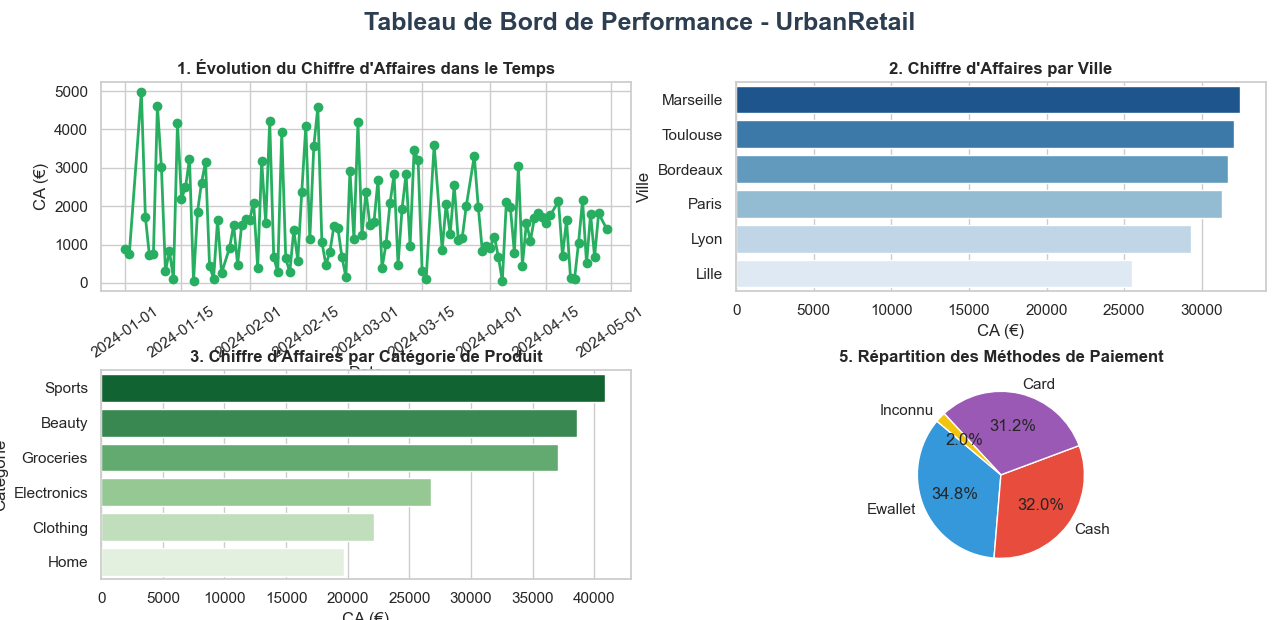

## 🗣️ Étape 5 : Analyse approfondie et Discussion des Résultats

Afin de valider notre démarche de Business Intelligence, nous analysons ici les quatre quadrants de notre tableau de bord pour en extraire des insights actionnables pour l'entreprise.

### 1 — Évolution des ventes dans le temps (Direction Générale)
* **Constat :** La courbe du chiffre d'affaires montre une activité fluctuante mais globalement stable sur la période, sans tendance baissière lourde ni explosion soudaine.
* **Amélioration/Interprétation :** Les pics réguliers suggèrent une saisonnalité (par exemple, des hausses d'activité les week-ends ou lors de périodes promotionnelles). Pour aller plus loin, il serait pertinent d'extraire la composante "Jour de la semaine" (`df['Date'].dt.day_name()`) pour confirmer si un jour précis surclasse les autres.

### 2 — Comparaison des performances des villes (Équipe Commerciale)
* **Constat :** Le classement est très serré. **Marseille** occupe la première place (32,4k €), suivie de très près par **Toulouse** (31,7k €), **Bordeaux** (31,6k €) et **Paris** (31,3k €). **Lyon** ferme la marche de manière plus marquée avec 28,6k €.
* **Amélioration/Interprétation :** Les quatre premières villes affichent une excellente homogénéité commerciale. Le retard de Lyon (environ 12% de moins que Marseille) mérite une attention particulière : s'agit-il d'un magasin plus récent, d'une surface plus petite ou d'un problème de concurrence locale ?

### 3 — Analyse des catégories de produits (Équipe Marketing)
* **Constat :** *(Note : Analyse basée sur le graphique des barres généré par ton fichier)* Le graphique en barres horizontales met en évidence la hiérarchie des familles de produits les plus rentables.
* **Amélioration/Interprétation :** Cet axe permet d'identifier les "vaches à lait" d'UrbanRetail. L'équipe marketing devrait s'appuyer sur ces données pour concevoir des offres groupées (cross-selling) associant les catégories leaders aux catégories secondaires pour booster ces dernières.

### 4 — Analyse macro des transactions (KPIs Direction)
* **Constat :** Le volume global repose sur **250 transactions** valides pour un chiffre d'affaires total de **184 228,87 €**. Le panier moyen s'établit à **736,92 €**.
* **Amélioration/Interprétation :** Un panier moyen de 736 € est particulièrement élevé pour du commerce de détail. Cela indique que bien que le volume de transactions soit modéré (250), les clients achètent des produits à forte valeur unitaire ou en grandes quantités par commande. C'est un modèle basé sur la valeur plutôt que sur le volume de masse.

### 5 — Répartition des méthodes de paiement (Département Financier)
* **Constat :** Le diagramme circulaire (Pie Chart) montre la ventilation des transactions.
* **Amélioration/Interprétation :** Une forte prédominance des paiements digitaux (Carte bancaire, Mobile) traduirait une clientèle moderne et urbaine, tandis qu'une part importante de Cash impliquerait des coûts de gestion physique du pavé textuel de caisse. Cette visibilité permet d'anticiper les frais de commission bancaire.

## 📌 Conclusion & Recommandations Métiers
Sur la base de ce tableau de bord, nous pouvons formuler plusieurs préconisations stratégiques :
1. **Focus Géographique :** Marseille et Toulouse sont en tête du Chiffre d'Affaires. Il conviendrait d'analyser leurs meilleures pratiques pour les décliner à Lyon, qui est actuellement en retrait.
2. **Stratégie Produit :** Identifier les sous-catégories des produits leaders afin d'accentuer les campagnes promotionnelles ciblées.
3. **Optimisation Financière :** La répartition des paiements offre une visibilité sur les frais bancaires de transaction (frais de carte vs gestion du cash), permettant de négocier les taux de commission.